**How to run.** This notebook is self-contained — it trains, evaluates, and plots the Fig. S3e panel itself, with no external scripts.

- `TRAIN = False` (default): evaluate the checkpoints already in `CKPT_DIR` (`revision_rerun`) leave-one-plate-out, write `results/sample_size_experiment/HN_patients.csv` and `HN_plates.csv`, and draw the panel.
- `TRAIN = True`: first train the subsampled models with the loop below — one model per configuration at 500k iterations into `CKPT_DIR` (slow). Each model is restricted to patients not on the held-out plate (including shared healthy donors), as in Fig. 3g. Grid: patients n ∈ {6, 12, 18} × 5 random seeds; plates k ∈ {1, 2} × all three plate-combinations.
- The full-training-set point reuses the paper’s existing `3_12_t01_healthy_groups_without_plate_{p}_mil` checkpoints (equals Fig. 3g).

# Cancer-type MIL — Head & Neck sample-size experiment

Tests the manuscript's explanation that the weaker classification of Meningioma and
Chordoma/Chondrosarcoma is partly due to *fewer usable samples/plates* than Head & Neck.
We retrain the cancer-type MIL classifier while shrinking **only the Head & Neck** training
set (holding the other groups fixed) and measure how Head & Neck accuracy changes.

Protocol is identical to [`cancer_type_mil.ipynb`](cancer_type_mil.ipynb) / Fig. 3g:
`GatedAttentionMulti` (4 classes, 5 branches), leave-one-plate-out over plates 3–12,
500k iterations, lr 1e-4, ColorJitter + flips, and the same leave-one-plate-out
protocol (the held-out plate's patients are excluded from training) so results are
directly comparable to Fig. 3g.

Two axes, evaluated on the four Head & Neck folds (plates 3–6):
* **B1** — subsample the number of Head & Neck training *patients*: n ∈ {6, 12, 18} (+ full).
* **B2** — subsample the number of Head & Neck training *plates*: k ∈ {1, 2} (+ full = 3).

The full-data point reuses the paper's existing `3_12_t01_healthy_groups_without_plate_{p}_mil`
checkpoints (it equals Fig. 3g, H&N accuracy = 0.58).

> Training these models at 500k iterations is slow, so this notebook evaluates the existing
> checkpoints by default (`TRAIN = False`). Set `TRAIN = True` to (re)train the subsampled
> models with the loop below.


In [1]:
from data import PlateDataset
from util import torch_random_choice
from models import GatedAttentionMulti
from training import train_model

import os
from itertools import combinations
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

device = 'cuda:0'                 # change to an available GPU
TRAIN = False                     # True -> train here (slow); False -> only eval existing checkpoints
NUM_ITER = 500_000
TRAIN_SEED = 12341
SEEDS = [0, 1, 2, 3, 4]           # random subsampling draws per configuration (error bars)
CKPT_DIR = '/ewsc/hschluet/models/pbmc5/revision_rerun'
CKPT_FULL = '/ewsc/hschluet/models/pbmc5/revision_rerun'   # existing Fig. 3g checkpoints (full-data point)
RES_DIR = 'results/sample_size_experiment'
os.makedirs(CKPT_DIR, exist_ok=True); os.makedirs(RES_DIR, exist_ok=True)
aug = T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2), T.RandomHorizontalFlip(), T.RandomVerticalFlip()])

In [2]:
data = PlateDataset([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

use_groups = ['healthy', 'H&N cancer', 'CNS-Meningioma', 'Chordoma/Chondrosarcoma']
group_map = {'healthy': 0, 'H&N cancer': 1, 'CNS-Meningioma': 2, 'Chordoma/Chondrosarcoma': 3}
HN = group_map['H&N cancer']
GRP_PLATES = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
HN_PLATES = [3, 4, 5, 6]          # plates containing Head & Neck patients

cdf = data.info[data.info['group'].isin(use_groups)].groupby(['patient', 'time'])['cell'].count().reset_index()
cdf = cdf[cdf['cell'] > 100]
p01s = cdf[cdf['time'].isin([0, 1])]['patient'].unique()

  0%|          | 0/10 [00:00<?, ?it/s]

 20%|██        | 2/10 [00:00<00:01,  4.39it/s]

 30%|███       | 3/10 [00:00<00:01,  4.13it/s]

 40%|████      | 4/10 [00:01<00:01,  3.56it/s]

 50%|█████     | 5/10 [00:01<00:01,  3.25it/s]

...

 70%|███████   | 7/10 [00:02<00:00,  3.37it/s]

 80%|████████  | 8/10 [00:02<00:00,  3.44it/s]

 90%|█████████ | 9/10 [00:02<00:00,  4.02it/s]

100%|██████████| 10/10 [00:02<00:00,  3.23it/s]

100%|██████████| 10/10 [00:02<00:00,  3.46it/s]

In [3]:
# ---- bagloaders (identical to cancer_type_mil.ipynb) ----
def group_bagloader(use_patients=p01s, use_plates=GRP_PLATES, bag_size=50, transform=T.CenterCrop(28)):
    use_idx = torch.argwhere(torch.from_numpy(
        (data.info['plate'].isin(use_plates) & data.info['time'].isin([0, 1])).values)).flatten()
    use_data = transform(data.imgs[use_idx].to(device))
    plate_pats = np.concatenate(data.info.groupby('plate')['patient'].unique().loc[use_plates].values)
    use_patients = np.array(use_patients)[np.isin(use_patients, plate_pats)]
    pat_by_group = data.info.groupby('group')['patient'].unique().map(lambda x: x[np.isin(x, use_patients)])
    pat_lut = {pat: torch.argwhere(torch.from_numpy(
        (data.info.loc[use_idx]['patient'] == pat).values)).flatten().to(device) for pat in use_patients}
    while True:
        label = np.random.choice(use_groups)
        pat = np.random.choice(pat_by_group[label])
        xs = use_data[torch_random_choice(pat_lut[pat], size=bag_size)]
        yield xs.float(), torch.tensor(group_map[label]).to(device)

def test_group_bagloader(use_plates, use_patients=p01s, bag_size=50, reps=5, transform=T.CenterCrop(28)):
    use_idx = torch.argwhere(torch.from_numpy(
        (data.info['plate'].isin(use_plates) & data.info['time'].isin([0, 1])).values)).flatten()
    use_data = transform(data.imgs[use_idx].to(device))
    pat_groups = data.info.groupby('patient')['group'].max()
    pat_plates = data.info.groupby('patient')['plate'].unique()
    for pat in use_patients:
        if not np.isin(pat_plates[pat], use_plates).any():
            continue
        pat_idx = torch.argwhere(torch.from_numpy(
            (data.info.loc[use_idx]['patient'] == pat).values)).flatten().to(device)
        for _ in range(reps):
            xs = use_data[torch_random_choice(pat_idx, size=bag_size)]
            yield xs.float(), torch.tensor(group_map[pat_groups[pat]]).to(device), pat, pat_groups[pat]

In [4]:
# ---- build the subsampling jobs (deterministic patient lists) ----
pat_group = data.info.groupby('patient')['group'].max()
pat_plate = data.info.groupby('patient')['plate'].first()
pat_on_plate = data.info.groupby('plate')['patient'].unique()      # patients on each plate
HN_pats = np.array([p for p in p01s if pat_group[p] == 'H&N cancer'])
non_HN = [p for p in p01s if pat_group[p] != 'H&N cancer']
HN_by_plate = {pl: [p for p in HN_pats if pat_plate[p] == pl] for pl in HN_PLATES}
print('H&N patients per plate:', {pl: len(v) for pl, v in HN_by_plate.items()}, '| total', len(HN_pats))

jobs = []
for fold_p in HN_PLATES:                                            # held-out plate
    drop = set(pat_on_plate.loc[fold_p])                           # drop held-out plate's patients (incl. shared donors)
    def clean(pats):
        return [p for p in pats if p not in drop]
    train_plates = [p for p in GRP_PLATES if p != fold_p]
    train_HN_plates = [pl for pl in HN_PLATES if pl != fold_p]
    avail = np.array([p for pl in train_HN_plates for p in HN_by_plate[pl]])
    for n in [6, 12, 18]:                                           # subsample # H&N patients
        if n >= len(avail):
            continue
        for seed in SEEDS:
            rng = np.random.default_rng(10_000 * fold_p + 100 * n + seed)
            jobs.append({'name': f'HN_patients_p{fold_p}_n{n}_s{seed}', 'plates': train_plates,
                         'patients': clean(list(rng.choice(avail, n, replace=False)) + non_HN)})
    for k in [1, 2]:                                                # subsample # H&N plates (all combos)
        for ci, combo in enumerate(combinations(sorted(train_HN_plates), k)):     # 3 combos each
            sub_HN = [p for pl in combo for p in HN_by_plate[pl]]
            jobs.append({'name': f'HN_plates_p{fold_p}_k{k}_c{ci}', 'plates': train_plates,
                         'patients': clean(sub_HN + non_HN)})
print(f'{len(jobs)} training jobs '
      f'({sum("HN_patients" in j["name"] for j in jobs)} patient-subsamples, '
      f'{sum("HN_plates" in j["name"] for j in jobs)} plate-subsamples)')

H&N patients per plate: {3: 4, 4: 9, 5: 8, 6: 10} | total 31
84 training jobs (60 patient-subsamples, 24 plate-subsamples)


In [5]:
# ---- training loop (sequential; skips existing checkpoints). Set TRAIN=True to run. ----
if TRAIN:
    for job in jobs:
        if os.path.exists(f'{CKPT_DIR}/{job["name"]}_model.pt'):
            continue
        print('training', job['name'])
        model = GatedAttentionMulti(classes=4, branches=5)
        train_model(model, bag_loader=group_bagloader(job['patients'], job['plates']),
                    num_iter=NUM_ITER, lr=0.0001, device=device, fname=job['name'], outdir=CKPT_DIR,
                    save_model=True, seed=TRAIN_SEED, plot=False, bar=False, transform=aug)
else:
    have = sum(os.path.exists(f'{CKPT_DIR}/{j["name"]}_model.pt') for j in jobs)
    print(f'TRAIN=False -> evaluating existing checkpoints ({have}/{len(jobs)} present). '
          'Set TRAIN=True to train the missing ones.')

TRAIN=False -> evaluating existing checkpoints (84/84 present). Set TRAIN=True to train the missing ones.


In [6]:
# ---- evaluate (leave-one-plate-out) and aggregate Head & Neck accuracy ----
def eval_on_plate(ckpt, fold_p):
    model = GatedAttentionMulti(classes=4, branches=5).to(device)
    model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
    model.eval()
    np.random.seed(1232412); torch.manual_seed(124514); torch.cuda.manual_seed_all(13513)
    rows = []
    for i, (bag, lab, pat, group) in enumerate(test_group_bagloader(use_plates=[fold_p])):
        with torch.no_grad():
            _, pred, *_ = model(bag.to(device))
        rows.append({'pat': pat, 'true': int(lab.item()), 'pred': int(pred.cpu().item())})
    return pd.DataFrame(rows)

def hn_accuracy(name_fn=None, full=False):
    dfs = []
    for p in HN_PLATES:
        ckpt = (f'{CKPT_FULL}/3_12_t01_healthy_groups_without_plate_{p}_mil_model.pt' if full
                else f'{CKPT_DIR}/{name_fn(p)}_model.pt')
        if not os.path.exists(ckpt):
            return None
        dfs.append(eval_on_plate(ckpt, p))
    pv = pd.concat(dfs).groupby(['pat', 'true'])['pred'].agg(lambda x: x.mode()[0]).reset_index()
    hn = pv[pv['true'] == HN]
    return float((hn['pred'] == HN).mean())

full_acc = hn_accuracy(full=True)
patients = [{'n_HN_train': 'all', 'seed': 'full', 'hn_acc': full_acc}]
for n in [6, 12, 18]:
    for seed in SEEDS:
        a = hn_accuracy(lambda p, n=n, seed=seed: f'HN_patients_p{p}_n{n}_s{seed}')
        if a is not None:
            patients.append({'n_HN_train': n, 'seed': seed, 'hn_acc': a})
plates = [{'k_HN_plates': 3, 'seed': 'full', 'hn_acc': full_acc}]
for k in [1, 2]:
    for ci in range(3):                       # the 3 plate combinations per fold
        a = hn_accuracy(lambda p, k=k, ci=ci: f'HN_plates_p{p}_k{k}_c{ci}')
        if a is not None:
            plates.append({'k_HN_plates': k, 'seed': ci, 'hn_acc': a})
patients = pd.DataFrame(patients); plates = pd.DataFrame(plates)
patients.to_csv(f'{RES_DIR}/HN_patients.csv', index=False); plates.to_csv(f'{RES_DIR}/HN_plates.csv', index=False)
print('full-data H&N accuracy (= Fig. 3g):', round(full_acc, 3))
display(patients.groupby('n_HN_train')['hn_acc'].mean().round(3))
display(plates.groupby('k_HN_plates')['hn_acc'].mean().round(3))

full-data H&N accuracy (= Fig. 3g): 0.581


n_HN_train
6      0.226
12     0.335
18     0.484
all    0.581
Name: hn_acc, dtype: float64

k_HN_plates
1    0.194
2    0.376
3    0.581
Name: hn_acc, dtype: float64

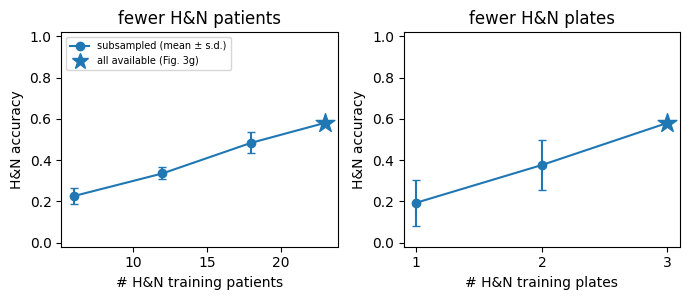

In [7]:
# ---- Fig. S3e panel: Head & Neck accuracy vs. its own training-set size ----
BLUE = 'tab:blue'; FULL_X = 23     # mean # H&N training patients across LOPO folds (21-27)
fig, axs = plt.subplots(1, 2, figsize=(7, 3.1))

sub = patients[patients['seed'] != 'full'].copy(); sub['n_HN_train'] = sub['n_HN_train'].astype(int)
g = sub.groupby('n_HN_train')['hn_acc'].agg(['mean', 'std']).reset_index()
full = patients.loc[patients['seed'] == 'full', 'hn_acc'].iloc[0]
axs[0].plot(list(g['n_HN_train']) + [FULL_X], list(g['mean']) + [full], '-', color=BLUE, zorder=1)
axs[0].errorbar(g['n_HN_train'], g['mean'], yerr=g['std'].fillna(0), fmt='o', capsize=3, color=BLUE, zorder=3)
axs[0].scatter([FULL_X], [full], marker='*', s=200, color=BLUE, zorder=5)
axs[0].set(title='fewer H&N patients', xlabel='# H&N training patients', ylabel='H&N accuracy', ylim=(-0.02, 1.02))

sub = plates[plates['seed'] != 'full'].copy(); sub['k_HN_plates'] = sub['k_HN_plates'].astype(int)
g = sub.groupby('k_HN_plates')['hn_acc'].agg(['mean', 'std']).reset_index()
full = plates.loc[plates['seed'] == 'full', 'hn_acc'].iloc[0]
axs[1].plot(list(g['k_HN_plates']) + [3], list(g['mean']) + [full], '-', color=BLUE, zorder=1)
axs[1].errorbar(g['k_HN_plates'], g['mean'], yerr=g['std'].fillna(0), fmt='o', capsize=3, color=BLUE, zorder=3)
axs[1].scatter([3], [full], marker='*', s=200, color=BLUE, zorder=5)
axs[1].set(title='fewer H&N plates', xlabel='# H&N training plates', ylabel='H&N accuracy', ylim=(-0.02, 1.02), xticks=[1, 2, 3])

handles = [mlines.Line2D([], [], color=BLUE, marker='o', linestyle='-', label='subsampled (mean ± s.d.)'),
           mlines.Line2D([], [], color=BLUE, marker='*', linestyle='None', markersize=12, label='all available (Fig. 3g)')]
axs[0].legend(handles=handles, fontsize=7, loc='upper left')
fig.tight_layout()